In [ ]:
import os
import pandas as pd
from utils import DATASETS, plot_bar

plot_dir = f'../plot/others'
os.makedirs(plot_dir, exist_ok=True)

question_nums, testtaker_nums = [], []
for dataset in DATASETS:
    y = pd.read_csv(f'../data/pre_calibration/{dataset}/matrix.csv', index_col=0).values
    testtaker_nums.append(y.shape[0])
    question_nums.append(y.shape[1])

plot_bar(DATASETS, question_nums, f"{plot_dir}/question_nums.png", r"Number of Questions", exp_axis=True)
plot_bar(DATASETS, testtaker_nums, f"{plot_dir}/testtaker_nums.png", r"Number of Test Takers")

In [2]:

import pandas as pd
from utils import plot_corr, plot_corr_double
import os

plot_dir = f'../plot/overall'
os.makedirs(plot_dir, exist_ok=True)

nonamor4plugin_gof_train = pd.read_csv(f'../plot/nonamor_calibration/nonamor4plugin_gof_train.csv')["gof_means"].values
nonamor4plugin_gof_test = pd.read_csv(f'../plot/nonamor_calibration/nonamor4plugin_gof_test.csv')["gof_means"].values
nonamor4amor_gof_train = pd.read_csv(f'../plot/nonamor_calibration/nonamor4amor_gof_train.csv')["gof_means"].values
nonamor4amor_gof_test = pd.read_csv(f'../plot/nonamor_calibration/nonamor4amor_gof_test.csv')["gof_means"].values
amor_gof_train = pd.read_csv(f'../plot/amor_calibration/amor_single_gof_train.csv')["gof_means"].values
amor_gof_test = pd.read_csv(f'../plot/amor_calibration/amor_single_gof_test.csv')["gof_means"].values
plugin_gof_train = pd.read_csv(f'../plot/plugin_regression/plugin_single_gof_train.csv')["gof_means"].values
plugin_gof_test = pd.read_csv(f'../plot/plugin_regression/plugin_single_gof_test.csv')["gof_means"].values

nonamor_ctt = pd.read_csv(f'../plot/nonamor_calibration/nonamor_calibration_corr_ctt.csv')["corr_ctt_means"].values
amor_ctt = pd.read_csv(f'../plot/amor_calibration/amor_calibration_corr_ctt.csv')["corr_ctt_means"].values

nonamor_helm = pd.read_csv(f'../plot/nonamor_calibration/nonamor_calibration_corr_helm.csv')["corr_helm_means"].values
amor_helm = pd.read_csv(f'../plot/amor_calibration/amor_calibration_corr_helm.csv')["corr_helm_means"].values

plot_corr(
    data1=nonamor_ctt,
    data2=amor_ctt,
    plot_path=f"{plot_dir}/ctt_nonamor_amor.png",
    title=r'$\theta$ correlation with CTT. $\rho$ = {:.2f}',
    xlabel=r"Non-amortization",
    ylabel=r"Functional amortization",
)

plot_corr(
    data1=nonamor_helm,
    data2=amor_helm,
    plot_path=f"{plot_dir}/helm_nonamor_amor.png",
    title=r'$\theta$ correlation with HELM. $\rho$ = {:.2f}',
    xlabel=r"Non-amortization",
    ylabel=r"Functional amortization",
)

plot_corr_double(
    data1_train=nonamor4amor_gof_train,
    data1_test=nonamor4amor_gof_test,
    data2_train=amor_gof_train,
    data2_test=amor_gof_test,
    plot_path=f"{plot_dir}/gof_nonamor_amor.png",
    xlabel=r"Non-amortization",
    ylabel=r"Functional amortization",
)

plot_corr_double(
    data1_train=nonamor4plugin_gof_train,
    data1_test=nonamor4plugin_gof_test,
    data2_train=plugin_gof_train,
    data2_test=plugin_gof_test,
    plot_path=f"{plot_dir}/gof_nonamor_plungin.png",
    xlabel=r"Non-amortization",
    ylabel=r"Plug-in amortization",
)

In [2]:
import os
import pandas as pd
from sklearn.metrics import mean_squared_error

task_list = ['plugin_regression/aggregate_byrandom']
pattern = ['train', 'test']

directory = '../data/plugin_regression/aggregate_byrandom'
file_pattern = 'test'

concat_df = pd.DataFrame()
for filename in os.listdir(directory):
    if filename.startswith(file_pattern) and filename.endswith('.csv'):
        file_path = os.path.join(directory, filename)
        df = pd.read_csv(file_path)
        concat_df = pd.concat([concat_df, df[['z_true', 'z_pred']]])

mse = mean_squared_error(concat_df['z_true'], concat_df['z_pred'])
print(f"Mean Squared Error: {mse}")

Mean Squared Error: 161.60632292624604


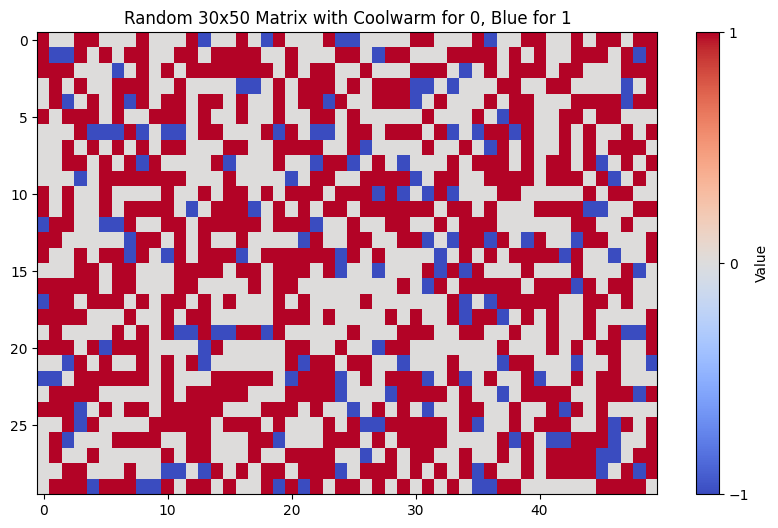

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.colors import ListedColormap
matrix = np.random.choice([-1, 0, 1], size=(30, 50), p=[0.1, 0.45, 0.45])
norm = Normalize(vmin=-1, vmax=1)
plt.figure(figsize=(10, 6))
plt.imshow(matrix, cmap='coolwarm', interpolation='none', aspect='auto', norm=norm)
plt.colorbar(ticks=[0, -1, 1], label='Value')
plt.title("Random 30x50 Matrix with Coolwarm for 0, Blue for 1")
plt.grid(False)
plt.show()